In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [97]:
df = sns.load_dataset("iris")

In [98]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [100]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [101]:
df.duplicated().sum()

np.int64(1)

<Axes: >

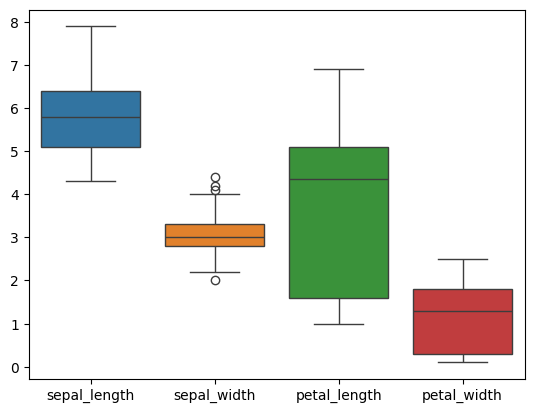

In [102]:
sns.boxplot(df)

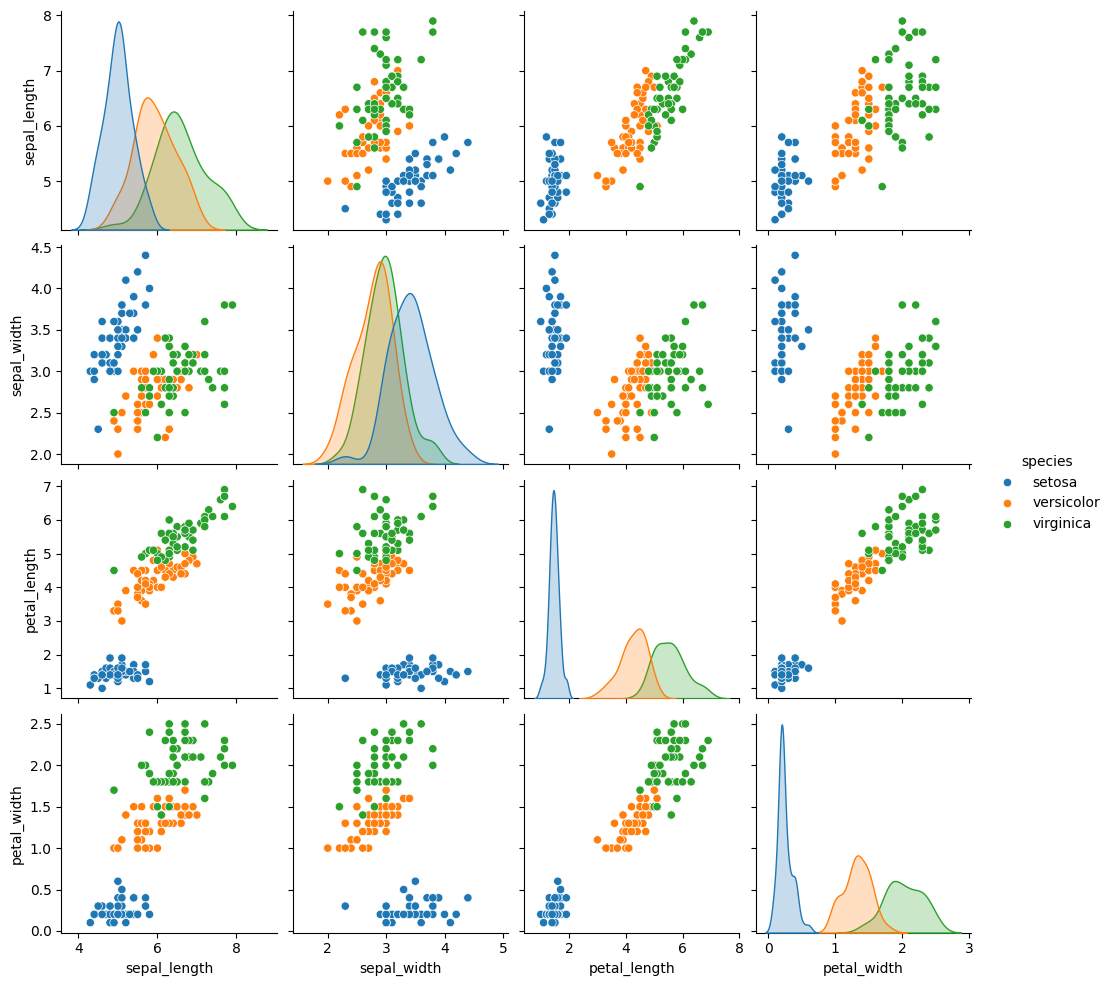

In [103]:
sns.pairplot(data=df, hue="species")

In [104]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["species"] = encoder.fit_transform(df["species"])

In [105]:
x = df.drop(columns=["species"])
y = df["species"]

In [106]:
y.value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [107]:
from sklearn.model_selection import train_test_split
xtrain , xtest , ytrain , ytest = train_test_split(x,y, test_size=0.2, shuffle=True, stratify=y, random_state= 42)

In [108]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [109]:
# model DT


In [110]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [111]:
model = DecisionTreeClassifier()
model.fit(xtrain,ytrain)
ypred = model.predict(xtest)
accuracy_score(ytest, ypred)

0.9333333333333333

In [112]:
x.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='str')

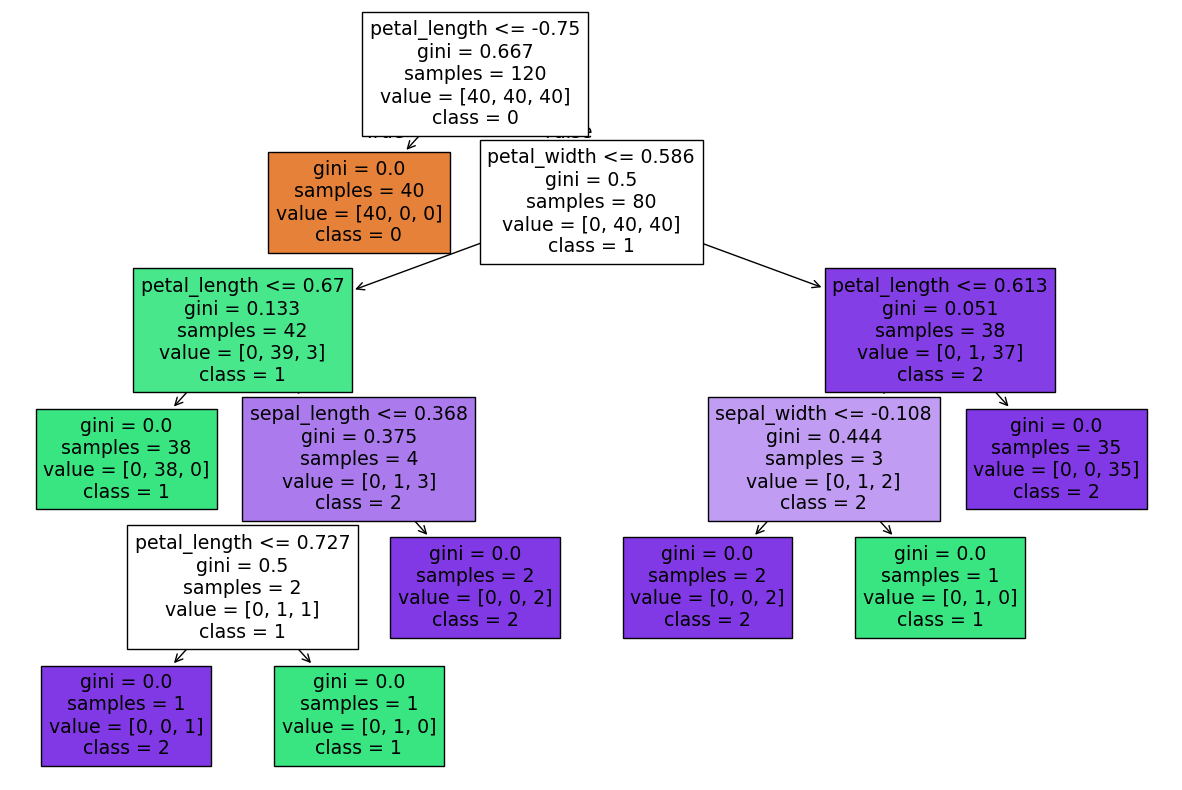

In [113]:
plt.figure(figsize=(15,10)) 
plot_tree(model,feature_names=x.columns, class_names=["0","1","2"], filled=True)
plt.show()

In [114]:
#check overfitting
train_acc = accuracy_score(ytrain , model.predict(xtrain))
test_acc = accuracy_score(ytest , model.predict(xtest))
print(train_acc)
print(test_acc)

1.0
0.9333333333333333


In [115]:
model.get_depth()

5

In [116]:
# votting
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.ensemble import VotingClassifier

In [117]:
model = VotingClassifier([
    ("lr" , LogisticRegression()),
    ("knn", KNeighborsClassifier()),
    ("DT", DecisionTreeClassifier()),
    ("svm", SVC())
])


model.fit(xtrain , ytrain)
pred = model.predict(xtest)
accuracy_score(ytest,ypred)

0.9333333333333333

In [118]:
#bagging
from sklearn.ensemble import BaggingClassifier

bagg_model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bagg_model.fit(xtrain,ytrain)
pred = model.predict(xtest)
accuracy_score(ytest,ypred)

0.9333333333333333

In [119]:
#random forest 
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=50)
model.fit(xtrain , ytrain)
pred = model.predict(xtest)
accuracy_score(ytest,ypred)

0.9333333333333333

In [120]:
# How to solve overfitting
#1 prunning ( pre , post )
#2 ensambling( bagging , boosting)

In [121]:
#regression
from sklearn.datasets import make_regression


In [122]:
X , y = make_regression(
    n_samples=1000, n_features=2, noise=30, random_state=42
)

In [123]:
X

array([[-0.16711808,  0.14671369],
       [-0.02090159,  0.11732738],
       [ 0.15041891,  0.364961  ],
       ...,
       [ 0.30263547, -0.75427585],
       [ 0.38193545,  0.43004165],
       [ 0.07736831, -0.8612842 ]], shape=(1000, 2))

In [124]:
df = pd.DataFrame(X, columns=["0", "1"])
df["target"] = y

In [125]:
df.head()

,0,1,target
0,-0.167118,0.146714,-33.320788
1,-0.020902,0.117327,-37.881384
2,0.150419,0.364961,36.260857
3,0.555604,0.089581,-26.436284
4,0.058209,-1.142970,-32.236561


In [126]:
x = df.drop(columns=["target"])
y=df["target"]

In [127]:
xtrain,xtest,ytrain,ytest= train_test_split(x, y ,test_size=0.2,random_state=42)

In [128]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

In [129]:
model = DecisionTreeRegressor()
model.fit(xtrain,ytrain)
print(mean_absolute_error(ytest, model.predict(xtest)))
print(mean_squared_error(ytest, model.predict(xtest)))
print(np.sqrt(mean_squared_error(ytest, model.predict(xtest))))


38.145623846331915
2189.3241984880547
46.7902147728353


In [130]:
# pre pruning
model = DecisionTreeRegressor(
    max_depth=5 , min_samples_split=15,min_samples_leaf=10
)
model.fit(xtrain,ytrain)
print(mean_absolute_error(ytest, model.predict(xtest)))
print(mean_squared_error(ytest, model.predict(xtest)))
print(np.sqrt(mean_squared_error(ytest, model.predict(xtest))))

25.89677004590286
1033.2813465070312
32.14469390905801


In [131]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(xtrain,ytrain)
print(mean_absolute_error(ytest, model.predict(xtest)))
print(mean_squared_error(ytest, model.predict(xtest)))
print(np.sqrt(mean_squared_error(ytest, model.predict(xtest))))

27.201559143975082
1171.4071687557894
34.22582604928316


In [132]:
model = RandomForestRegressor( max_depth=5 , min_samples_split=15,min_samples_leaf=10)
model.fit(xtrain,ytrain)
print(mean_absolute_error(ytest, model.predict(xtest)))
print(mean_squared_error(ytest, model.predict(xtest)))
print(np.sqrt(mean_squared_error(ytest, model.predict(xtest))))

25.11232520201772
995.2994094459004
31.54836619297266


In [133]:
! pip install xgboost

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [134]:
! py -m pip install xgboost

In [135]:
from xgboost import XGBRFClassifier

In [136]:
from xgboost import XGBRegressor

In [137]:
import  xgboost  as xgb

In [138]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [139]:
model = xgb.XGBClassifier()
model.fit(xtrain , ytrain)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 

In [ ]:
model = XGBRegressor()
model.fit(xtrain,ytrain)
print(mean_absolute_error(ytest, model.predict(xtest)))
print(mean_squared_error(ytest, model.predict(xtest)))
print(np.sqrt(mean_squared_error(ytest, model.predict(xtest))))

27.55635495416033
1225.9007911483372
35.012866080175975


In [140]:
model = XGBRegressor()
model.fit(xtrain,ytrain)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [141]:
print(mean_absolute_error(ytest, model.predict(xtest)))
print(mean_squared_error(ytest, model.predict(xtest)))
print(np.sqrt(mean_squared_error(ytest, model.predict(xtest))))

27.55635495416033
1225.9007911483372
35.012866080175975


In [142]:
model = XGBRegressor(
    n_estimators= 500,
    learning_rate= 0.05,
    max_depth= 4,
    gamma=0.1,
    colsample_bytree=0.5,
    subsample= 0.8,
    reg_lambda=1
    
    
)
model.fit(xtrain,ytrain)
print(mean_absolute_error(ytest, model.predict(xtest)))
print(mean_squared_error(ytest, model.predict(xtest)))
print(np.sqrt(mean_squared_error(ytest, model.predict(xtest))))

26.637675566510175
1070.1656193434403
32.71338593517095
